# Notebook 4: Data Generation — CRN Motif Library

This notebook covers the `crn_surrogate.data.generation` sub-package, which provides:

- **8 canonical motif factories** — each encodes a biologically-motivated network topology
- **3 new propensity types** — Hill repression, combined activation-repression, and substrate inhibition
- **Parameter sampling** — log-uniform for rate constants, uniform for Hill coefficients
- **Viability curation** — filters degenerate dynamics before storing
- **Data generation pipeline** — end-to-end: sample → simulate → curate → save

By the end of this notebook we will have generated a small but usable training dataset.

In [1]:
import warnings
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 150, "font.size": 12, "axes.titlesize": 12})
TAB10 = plt.get_cmap("tab10").colors

## 1. New Propensity Types

Three new kinetic functions have been added to `crn_surrogate.crn.propensities`:

| Type | Formula | Use case |
|------|---------|----------|
| `hill_repression` | k_max / (1 + (X/K)^n) | Gene repression, negative feedback |
| `hill_activation_repression` | k_max · Hill_act(X_a) · Hill_rep(X_r) | Incoherent feedforward loop |
| `substrate_inhibition` | V_max · S / (K_m + S + S²/K_i) | Enzyme inhibited by excess substrate |

These complement the existing `hill` (activation), `mass_action`, `constant_rate`, and `enzyme_michaelis_menten` propensities.

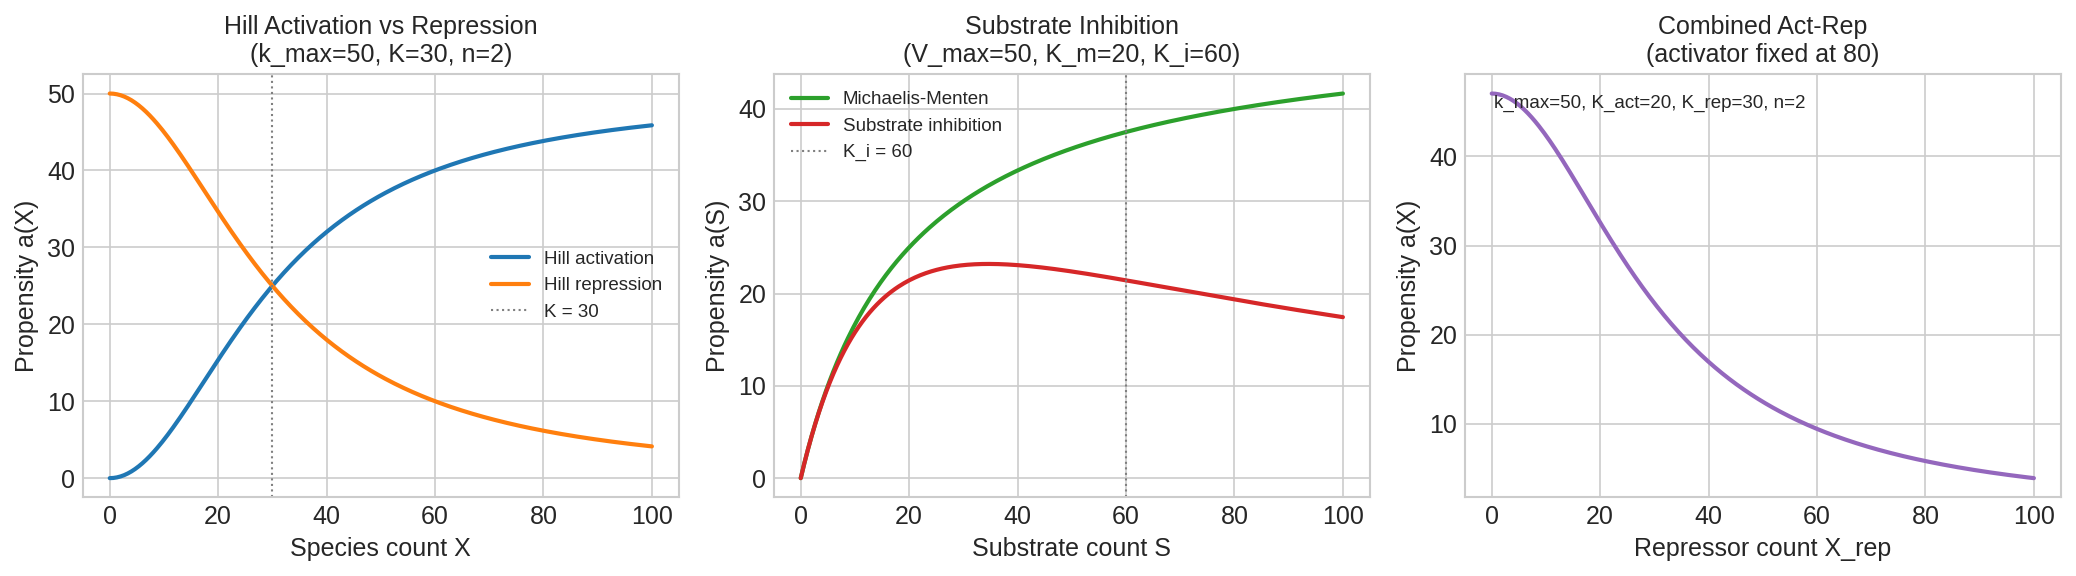

In [2]:
import torch
from crn_surrogate.crn.propensities import (
    hill_repression, hill_activation_repression, substrate_inhibition, hill,
)

x_vals = torch.linspace(0, 100, 300)

# --- Hill activation vs repression ---
p_act = hill(v_max=50.0, k_m=30.0, hill_coefficient=2.0, species_index=0)
p_rep = hill_repression(k_max=50.0, k_half=30.0, hill_coefficient=2.0, species_index=0)

act_rates = torch.stack([p_act(torch.tensor([x]), 0.0) for x in x_vals])
rep_rates = torch.stack([p_rep(torch.tensor([x]), 0.0) for x in x_vals])

# --- Substrate inhibition vs simple Michaelis-Menten ---
p_sub_inh = substrate_inhibition(v_max=50.0, k_m=20.0, k_i=60.0, species_index=0)
# MM equivalent (no inhibition term)
mm_rates = 50.0 * x_vals / (20.0 + x_vals + 1e-8)
sub_rates = torch.stack([p_sub_inh(torch.tensor([x]), 0.0) for x in x_vals])

# --- Combined activation-repression ---
# Activator fixed at 80, sweep repressor
x_act_fixed = torch.tensor([80.0, 0.0])
p_combined = hill_activation_repression(
    k_max=50.0, k_act=20.0, n_act=2.0, activator_index=0,
    k_rep=30.0, n_rep=2.0, repressor_index=1,
)
# Fix activator at 80, sweep repressor 0..100
rep_sweep = torch.linspace(0, 100, 300)
combined_rates = torch.stack([
    p_combined(torch.tensor([80.0, r.item()]), 0.0)
    for r in rep_sweep
])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_vals, act_rates.detach(), color=TAB10[0], lw=2, label="Hill activation")
axes[0].plot(x_vals, rep_rates.detach(), color=TAB10[1], lw=2, label="Hill repression")
axes[0].axvline(30, color="gray", linestyle=":", lw=1, label="K = 30")
axes[0].set_xlabel("Species count X")
axes[0].set_ylabel("Propensity a(X)")
axes[0].set_title("Hill Activation vs Repression\n(k_max=50, K=30, n=2)")
axes[0].legend(fontsize=9)

axes[1].plot(x_vals, mm_rates.detach(), color=TAB10[2], lw=2, label="Michaelis-Menten")
axes[1].plot(x_vals, sub_rates.detach(), color=TAB10[3], lw=2, label="Substrate inhibition")
axes[1].axvline(60, color="gray", linestyle=":", lw=1, label="K_i = 60")
axes[1].set_xlabel("Substrate count S")
axes[1].set_ylabel("Propensity a(S)")
axes[1].set_title("Substrate Inhibition\n(V_max=50, K_m=20, K_i=60)")
axes[1].legend(fontsize=9)

axes[2].plot(rep_sweep, combined_rates.detach(), color=TAB10[4], lw=2)
axes[2].set_xlabel("Repressor count X_rep")
axes[2].set_ylabel("Propensity a(X)")
axes[2].set_title("Combined Act-Rep\n(activator fixed at 80)")
axes[2].text(0.05, 0.92, "k_max=50, K_act=20, K_rep=30, n=2",
             transform=axes[2].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 2. Motif Catalogue

The generation library includes 8 canonical network motifs drawn from the systems biology literature. Each is implemented as a `MotifFactory` that returns a `CRN` object given a parameter dict.

| Motif | Species | Reactions | Key dynamics |
|-------|---------|-----------|-------------|
| Birth-death | 1 | 2 | Poisson stationary distribution |
| Auto-catalysis | 1 | 3 | Positive feedback, bistable regime |
| Negative autoregulation | 1 | 2 | Noise reduction, faster response |
| Toggle switch | 2 | 4 | Bistability (Gardner-Collins) |
| Enzymatic catalysis | 4 | 5 | Michaelis-Menten with explicit complex |
| Incoherent FFL | 3 | 6 | Pulse/adaptation response |
| Repressilator | 3 | 6 | Sustained oscillations (Elowitz & Leibler) |
| Substrate inhibition | 2 | 3 | Non-monotonic dose-response |

In [3]:
from crn_surrogate.data.generation.motifs import (
    BirthDeathFactory, AutoCatalysisFactory, NegativeAutoregulationFactory,
    ToggleSwitchFactory, EnzymaticCatalysisFactory, IncoherentFeedforwardFactory,
    RepressilatorFactory, SubstrateInhibitionMotifFactory,
)

factories = [
    BirthDeathFactory(),
    AutoCatalysisFactory(),
    NegativeAutoregulationFactory(),
    ToggleSwitchFactory(),
    EnzymaticCatalysisFactory(),
    IncoherentFeedforwardFactory(),
    RepressilatorFactory(),
    SubstrateInhibitionMotifFactory(),
]

print(f"{'Motif':<30} {'Species':<25} {'n_rxn':>5}")
print("-" * 65)
for f in factories:
    print(f"  {f.motif_type().value:<28} {str(f.species_names()):<25} {f.n_reactions():>5}")

Motif                          Species                   n_rxn
-----------------------------------------------------------------
  birth_death                  ('A',)                        2
  auto_catalysis               ('A',)                        3
  negative_autoregulation      ('A',)                        2
  toggle_switch                ('A', 'B')                    4
  enzymatic_catalysis          ('S', 'E', 'C', 'P')          5
  incoherent_feedforward       ('X', 'Y', 'Z')               6
  repressilator                ('A', 'B', 'C')               6
  substrate_inhibition         ('S', 'P')                    3


## 3. Example Trajectories per Motif

We use the parameter sampler to draw one configuration per motif and run a small SSA ensemble to illustrate the characteristic dynamics.

In [4]:
from crn_surrogate.data.generation.parameter_sampling import ParameterSampler
from crn_surrogate.data.generation.configs import SamplingConfig
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid

# Fixed-seed sampler for reproducibility
sampler = ParameterSampler(SamplingConfig(random_seed=42))
ssa = GillespieSSA()

T_MAX = 80.0
N_GRID = 200
N_TRAJ = 20
time_grid = torch.linspace(0, T_MAX, N_GRID)

# Fixed "interesting" params for each motif to ensure nice plots
fixed_params = [
    # BirthDeath
    {"k_prod": 10.0, "k_deg": 0.2, "A": 0.0},
    # AutoCatalysis
    {"k_basal": 1.0, "k_cat": 0.05, "k_deg": 0.1, "A": 5.0},
    # NegativeAutoregulation
    {"k_max": 40.0, "k_half": 20.0, "n_hill": 2.5, "k_deg": 0.15, "A": 0.0},
    # ToggleSwitch
    {"k_max_A": 50.0, "k_max_B": 50.0, "k_half_A": 25.0, "k_half_B": 25.0,
     "n_A": 3.0, "n_B": 3.0, "k_deg_A": 0.2, "k_deg_B": 0.2, "A": 40.0, "B": 2.0},
    # EnzymaticCatalysis
    {"k_on": 0.01, "k_off": 0.1, "k_cat": 0.3, "k_prod": 5.0, "k_deg_P": 0.1,
     "S": 50.0, "E": 20.0, "C": 0.0, "P": 0.0},
    # IncoherentFFL
    {"k_X": 5.0, "k_deg_X": 0.1, "k_max_Y": 20.0, "K_act_Y": 10.0, "n_act_Y": 2.0,
     "k_deg_Y": 0.15, "k_max_Z": 20.0, "K_act_Z": 10.0, "n_act_Z": 2.0,
     "K_rep_Z": 15.0, "n_rep_Z": 2.0, "k_deg_Z": 0.15, "X": 0.0, "Y": 0.0, "Z": 0.0},
    # Repressilator
    {"k_max_A": 80.0, "k_max_B": 80.0, "k_max_C": 80.0,
     "k_half_A": 20.0, "k_half_B": 20.0, "k_half_C": 20.0,
     "n_A": 3.0, "n_B": 3.0, "n_C": 3.0,
     "k_deg_A": 0.15, "k_deg_B": 0.15, "k_deg_C": 0.15,
     "A": 30.0, "B": 0.0, "C": 0.0},
    # SubstrateInhibition
    {"k_in": 5.0, "V_max": 20.0, "K_m": 15.0, "K_i": 60.0, "k_deg": 0.1,
     "S": 0.0, "P": 0.0},
]

print("Simulating example trajectories...")
all_trajs = {}
all_init = {}
for factory, params in zip(factories, fixed_params):
    crn = factory.create(params)
    init = torch.tensor([params.get(n, 0.0) for n in factory.species_names()], dtype=torch.float32)
    trajs = []
    for _ in range(N_TRAJ):
        res = ssa.simulate(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=init.clone(),
            t_max=T_MAX,
        )
        trajs.append(interpolate_to_grid(res.times, res.states, time_grid))
    all_trajs[factory.motif_type().value] = torch.stack(trajs)  # (N, T, n_species)
    all_init[factory.motif_type().value] = init
    print(f"  {factory.motif_type().value:<35} shape: {all_trajs[factory.motif_type().value].shape}")

Simulating example trajectories...
  birth_death                         shape: torch.Size([20, 200, 1])
  auto_catalysis                      shape: torch.Size([20, 200, 1])
  negative_autoregulation             shape: torch.Size([20, 200, 1])
  toggle_switch                       shape: torch.Size([20, 200, 2])
  enzymatic_catalysis                 shape: torch.Size([20, 200, 4])
  incoherent_feedforward              shape: torch.Size([20, 200, 3])
  repressilator                       shape: torch.Size([20, 200, 3])
  substrate_inhibition                shape: torch.Size([20, 200, 2])


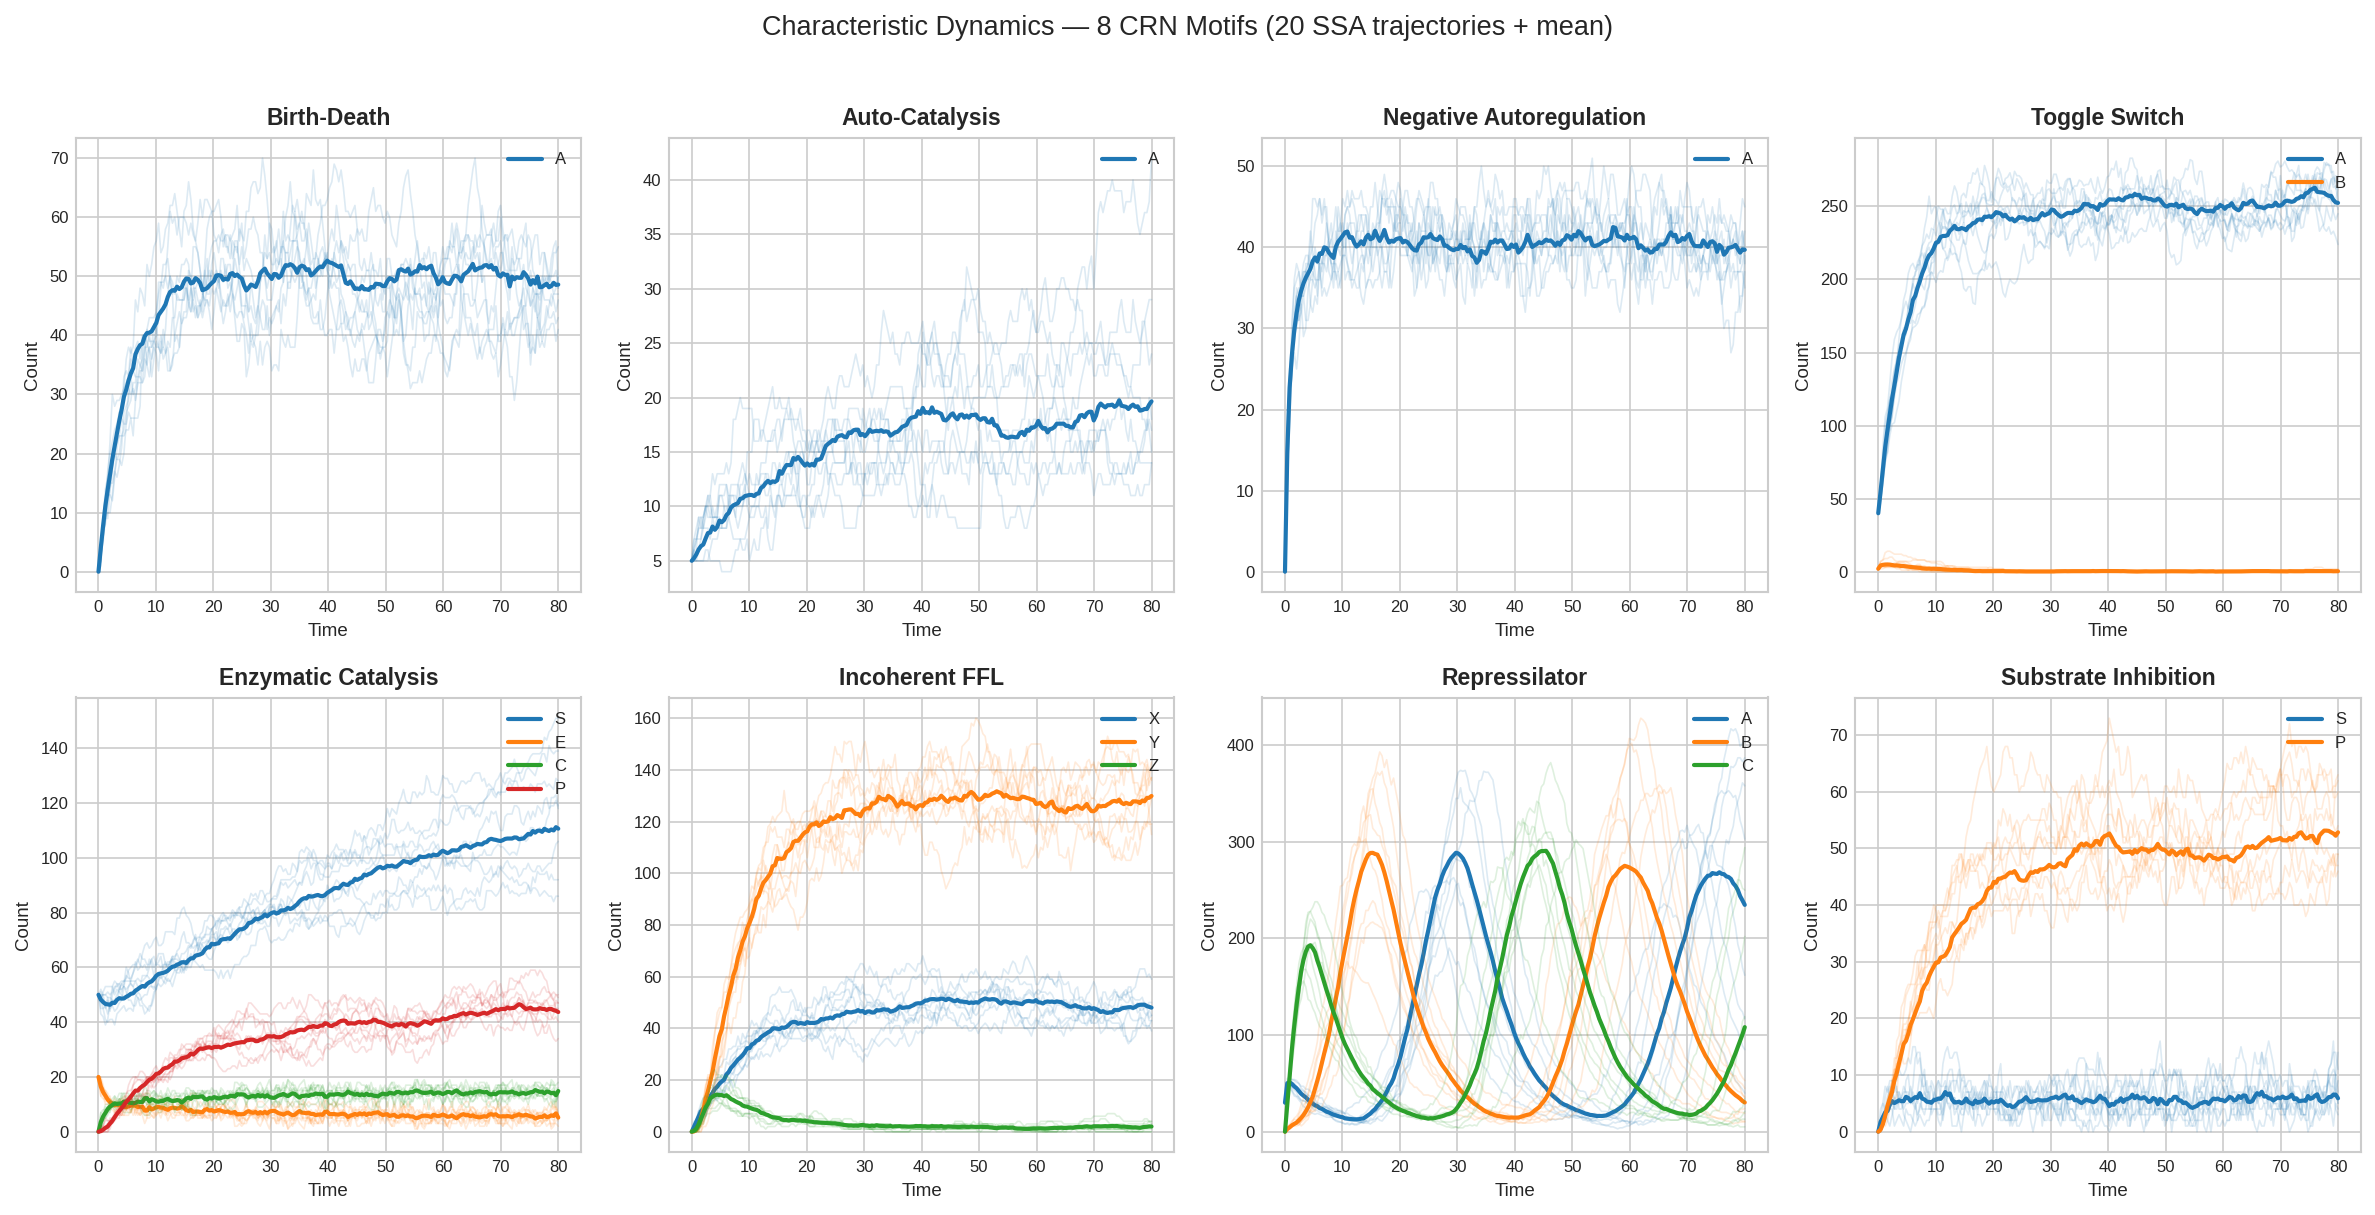

In [5]:
motif_labels = [
    ("birth_death",             "Birth-Death",                  ["A"]),
    ("auto_catalysis",          "Auto-Catalysis",               ["A"]),
    ("negative_autoregulation", "Negative Autoregulation",      ["A"]),
    ("toggle_switch",           "Toggle Switch",                ["A", "B"]),
    ("enzymatic_catalysis",     "Enzymatic Catalysis",          ["S", "E", "C", "P"]),
    ("incoherent_feedforward",  "Incoherent FFL",               ["X", "Y", "Z"]),
    ("repressilator",           "Repressilator",                ["A", "B", "C"]),
    ("substrate_inhibition",    "Substrate Inhibition",         ["S", "P"]),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()
t = time_grid.numpy()

for ax, (key, title, species) in zip(axes_flat, motif_labels):
    trajs = all_trajs[key]  # (N, T, n_sp)
    for sp_idx, sp_name in enumerate(species):
        color = TAB10[sp_idx % 10]
        # Individual trajectories (semi-transparent)
        for i in range(min(8, trajs.shape[0])):
            ax.plot(t, trajs[i, :, sp_idx].numpy(), alpha=0.15, lw=0.8, color=color)
        # Mean trajectory (solid)
        mean = trajs[:, :, sp_idx].mean(dim=0).numpy()
        ax.plot(t, mean, color=color, lw=2, label=sp_name)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=8)

plt.suptitle("Characteristic Dynamics — 8 CRN Motifs (20 SSA trajectories + mean)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Notes on each motif

- **Birth-death**: Poisson stationary distribution; mean = k_prod/k_deg = 50.
- **Auto-catalysis**: Positive feedback keeps A at a high stable level; initial population amplified by autocatalysis.
- **Negative autoregulation**: Hill repression creates a lower, tightly controlled steady state.
- **Toggle switch**: Bistability — from a high-A/low-B initial condition, A dominates; mutual repression locks in the state.
- **Enzymatic catalysis**: Complex C forms and turns over rapidly; product P accumulates at the rate set by k_cat.
- **Incoherent FFL**: Z shows an early pulse (X activates directly), then settles lower once Y (the repressor) builds up.
- **Repressilator**: Three-node ring oscillator with cooperative repression drives sustained oscillations in A, B, C out of phase.
- **Substrate inhibition**: S builds up until it inhibits its own conversion; steady state S is set by the balance of influx and inhibited catalysis.

## 4. Parameter Sampling

The `ParameterSampler` draws kinetic parameters from the ranges defined by each `MotifFactory`:

- **Rate constants** (`k_*`): log-uniform sampling — equal probability per decade
- **Hill coefficients** (`n_*`): uniform sampling — they live in a narrow range (1–5)
- **Initial states**: uniform integer sampling

Motif-specific constraints (e.g. k_deg > k_cat for auto-catalysis) are enforced by rejection sampling.

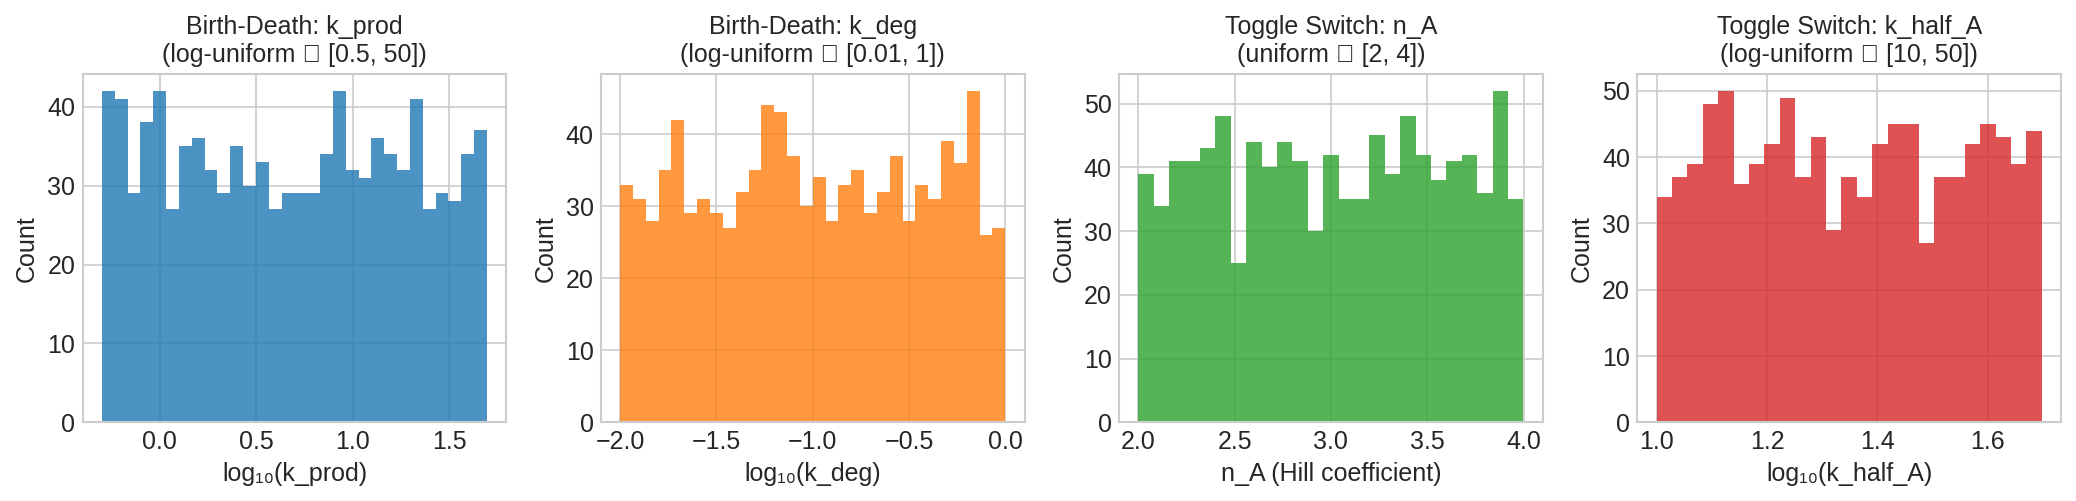

Auto-catalysis constraint violations (k_cat >= k_deg): 0/500
  Mean k_cat: 0.0153
  Mean k_deg: 0.1412


In [6]:
from crn_surrogate.data.generation.parameter_sampling import ParameterSampler
from crn_surrogate.data.generation.configs import SamplingConfig

sampler = ParameterSampler(SamplingConfig(n_samples_per_motif=1000, random_seed=0))

# Sample 1000 configs for birth-death and toggle switch
bd_params = sampler.sample(BirthDeathFactory(), n_samples=1000)
ts_params = sampler.sample(ToggleSwitchFactory(), n_samples=1000)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

# Birth-death: k_prod and k_deg on log scale
k_prod_vals = [p["k_prod"] for p in bd_params]
k_deg_vals  = [p["k_deg"]  for p in bd_params]
axes[0].hist(np.log10(k_prod_vals), bins=30, color=TAB10[0], alpha=0.8)
axes[0].set_xlabel("log\u2081\u2080(k_prod)")
axes[0].set_title("Birth-Death: k_prod\n(log-uniform \u2208 [0.5, 50])")
axes[1].hist(np.log10(k_deg_vals), bins=30, color=TAB10[1], alpha=0.8)
axes[1].set_xlabel("log\u2081\u2080(k_deg)")
axes[1].set_title("Birth-Death: k_deg\n(log-uniform \u2208 [0.01, 1])")

# Toggle switch: n_A (Hill coeff, uniform)
n_A_vals = [p["n_A"] for p in ts_params]
k_half_vals = [p["k_half_A"] for p in ts_params]
axes[2].hist(n_A_vals, bins=25, color=TAB10[2], alpha=0.8)
axes[2].set_xlabel("n_A (Hill coefficient)")
axes[2].set_title("Toggle Switch: n_A\n(uniform \u2208 [2, 4])")
axes[3].hist(np.log10(k_half_vals), bins=25, color=TAB10[3], alpha=0.8)
axes[3].set_xlabel("log\u2081\u2080(k_half_A)")
axes[3].set_title("Toggle Switch: k_half_A\n(log-uniform \u2208 [10, 50])")

for ax in axes:
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Verify autocatalysis constraint
ac_factory = AutoCatalysisFactory()
ac_params = sampler.sample(ac_factory, n_samples=500)
violations = sum(1 for p in ac_params if p["k_cat"] >= p["k_deg"])
print(f"Auto-catalysis constraint violations (k_cat >= k_deg): {violations}/500")
print(f"  Mean k_cat: {np.mean([p['k_cat'] for p in ac_params]):.4f}")
print(f"  Mean k_deg: {np.mean([p['k_deg'] for p in ac_params]):.4f}")

## 5. Viability Curation

Before storing a CRN configuration, the `ViabilityFilter` runs 6 checks on the SSA ensemble:

| Criterion | What it detects |
|-----------|----------------|
| NaN / Inf | Numerical instability |
| Blowup (> 10⁶) | Supercritical growth |
| Zero-stuck (> 95% zeros) | Network never fires |
| Low activity (< 10 transitions) | Network freezes immediately |
| Low CV (< 0.01) | Effectively deterministic — no stochasticity to learn |
| Unbounded final state (> 10⁵ mean) | Slow blowup |

Only configurations passing ALL checks are kept.

In [7]:
from crn_surrogate.data.generation.curation import ViabilityFilter, CurationResult
from crn_surrogate.data.generation.configs import CurationConfig

filt = ViabilityFilter(CurationConfig())

# Helper: make a (4, 50, 1) fake trajectory batch
def make_trajs(values):
    """values: list/array of shape (T,) -> broadcast to (4, T, 1)"""
    v = torch.tensor(values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    return v.expand(4, -1, -1)

t_grid = torch.linspace(0, 20, 50)

test_cases = [
    ("Good (birth-death)", None),          # will simulate for real below
    ("Blowup",        make_trajs([float(i * 1e5) for i in range(50)])),
    ("All zeros",     make_trajs([0.0] * 50)),
    ("Low activity",  make_trajs([10.0] * 50)),    # constant = no transitions
    ("Near-constant", make_trajs([100.0 + 0.001 * i for i in range(50)])),
    ("Huge final",    make_trajs([i * 4000.0 for i in range(50)])),
]

# Simulate a real birth-death trajectory for the "good" case
bd = BirthDeathFactory().create({"k_prod": 10.0, "k_deg": 0.2})
bd_trajs_list = []
for _ in range(4):
    res = ssa.simulate(
        stoichiometry=bd.stoichiometry_matrix,
        propensity_fn=bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=20.0,
    )
    bd_trajs_list.append(interpolate_to_grid(res.times, res.states, t_grid))
good_trajs = torch.stack(bd_trajs_list)  # (4, 50, 1)

print(f"{'Test case':<25}  {'Viable?':<8}  Reason")
print("-" * 55)
for name, trajs in test_cases:
    if trajs is None:
        trajs = good_trajs
    result = filt.check(trajs)
    status = "\u2713 PASS" if result.viable else "\u2717 FAIL"
    print(f"  {name:<23}  {status:<8}  {result.rejection_reason or '\u2014'}")

Test case                  Viable?   Reason
-------------------------------------------------------
  Good (birth-death)       ✓ PASS    —
  Blowup                   ✗ FAIL    blowup
  All zeros                ✗ FAIL    zero_stuck
  Low activity             ✗ FAIL    low_activity
  Near-constant            ✗ FAIL    low_cv
  Huge final               ✗ FAIL    unbounded_final


## 6. Generating a Small Training Dataset

Now we run the full pipeline. For demonstration, we use reduced counts (30 samples per motif, 8 SSA trajectories, 60 time points). This produces a dataset in ~2–5 minutes.

For a full training dataset, use the defaults: `n_samples_per_motif=500`, `n_ssa_trajectories=32`, `n_timepoints=200`.

In [8]:
import logging
import time
from crn_surrogate.data.generation.pipeline import DataGenerationPipeline
from crn_surrogate.data.generation.configs import (
    GenerationConfig, SamplingConfig, CurationConfig,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(name)s  %(message)s")

config = GenerationConfig(
    sampling=SamplingConfig(n_samples_per_motif=30, random_seed=42),
    curation=CurationConfig(),
    n_ssa_trajectories=8,
    simulation_time=50.0,
    n_timepoints=100,
    n_samples_per_motif=30,
    output_dir="data_cache/demo_dataset",
    random_seed=42,
)

pipeline = DataGenerationPipeline(config)

t0 = time.time()
summary = pipeline.run()
elapsed = time.time() - t0

print(f"\nGeneration complete in {elapsed:.1f}s")
print(f"Total viable items: {summary.total_items}")

INFO  crn_surrogate.data.generation.pipeline  birth_death: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  auto_catalysis: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  negative_autoregulation: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  toggle_switch: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  enzymatic_catalysis: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  incoherent_feedforward: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  repressilator: 30/30 viable
INFO  crn_surrogate.data.generation.pipeline  substrate_inhibition: 30/30 viable
WARNING  crn_surrogate.data.generation.pipeline  Motif 'birth_death' has only 30 viable configs (< 50)
WARNING  crn_surrogate.data.generation.pipeline  Motif 'auto_catalysis' has only 30 viable configs (< 50)
WARNING  crn_surrogate.data.generation.pipeline  Motif 'negative_autoregulation' has only 30 viable configs (< 50)
WARNING  crn_surrogate.data.generation.pipeline  Moti


Generation complete in 498.1s
Total viable items: 240


In [9]:
print("\nCuration statistics per motif:")
print(f"  {'Motif':<35} {'Sampled':>8} {'Passed':>8} {'Pass %':>8}  Rejection breakdown")
print("  " + "-" * 80)
for label, stats in summary.curation_stats.items():
    n = stats["n_sampled"]
    p = stats["n_passed"]
    rate = 100 * p / n if n > 0 else 0.0
    rejections = {k: v for k, v in stats.items()
                  if k not in ("n_sampled", "n_passed", "n_rejected") and v > 0}
    rej_str = ", ".join(f"{k}={v}" for k, v in rejections.items()) if rejections else "\u2014"
    print(f"  {label:<35} {n:>8} {p:>8} {rate:>7.0f}%  {rej_str}")

print(f"\nCluster ID map: {summary.cluster_id_map}")


Curation statistics per motif:
  Motif                                Sampled   Passed   Pass %  Rejection breakdown
  --------------------------------------------------------------------------------
  birth_death                               30       30     100%  —
  auto_catalysis                            30       30     100%  —
  negative_autoregulation                   30       30     100%  —
  toggle_switch                             30       30     100%  —
  enzymatic_catalysis                       30       30     100%  —
  incoherent_feedforward                    30       30     100%  —
  repressilator                             30       30     100%  —
  substrate_inhibition                      30       30     100%  —

Cluster ID map: {'auto_catalysis': 0, 'birth_death': 1, 'enzymatic_catalysis': 2, 'incoherent_feedforward': 3, 'negative_autoregulation': 4, 'repressilator': 5, 'substrate_inhibition': 6, 'toggle_switch': 7}


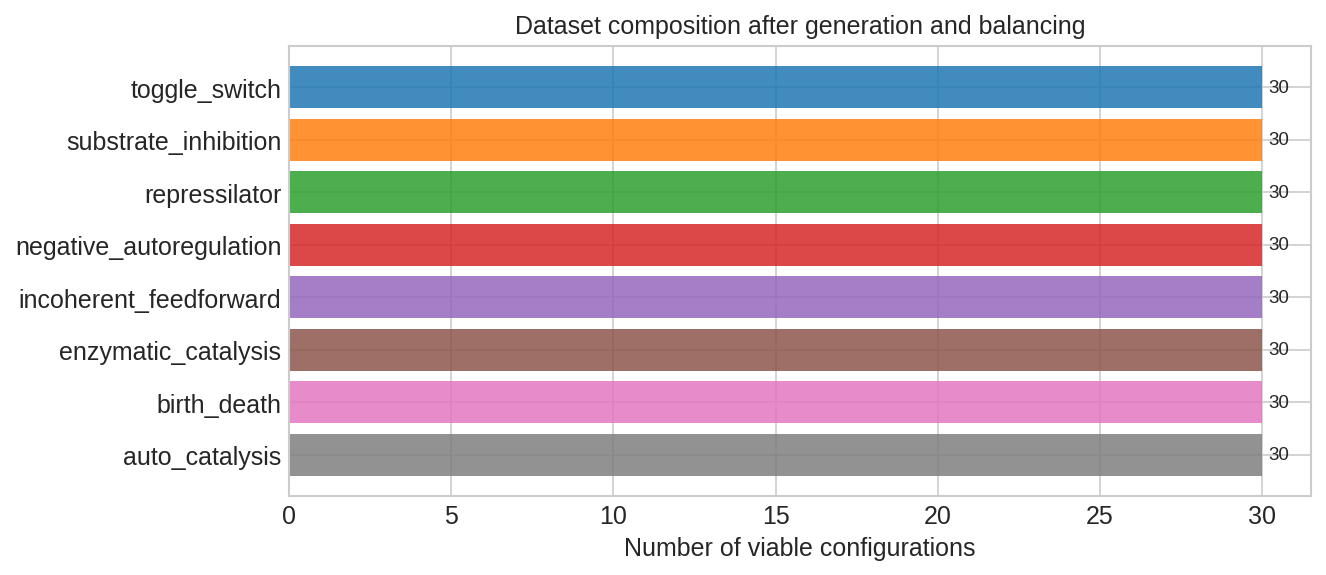

In [10]:
labels = list(summary.counts_per_motif.keys())
counts = list(summary.counts_per_motif.values())
sorted_pairs = sorted(zip(counts, labels), reverse=True)
counts_s, labels_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels_s, counts_s, color=[TAB10[i % 10] for i in range(len(labels_s))], alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of viable configurations")
ax.set_title("Dataset composition after generation and balancing")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Loading and Inspecting the Dataset

The dataset is saved as a `.pt` file containing a list of `TrajectoryItem` objects. `CRNTrajectoryDataset` can load it directly from the file path.

In [11]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, CRNCollator
from torch.utils.data import DataLoader

dataset = CRNTrajectoryDataset("data_cache/demo_dataset/dataset.pt")
print(f"Dataset size: {len(dataset)}")

item = dataset[0]
print(f"\nFirst item:")
print(f"  motif_label:          {item.motif_label}")
print(f"  cluster_id:           {item.cluster_id}")
print(f"  n_species:            {item.crn_repr.n_species}")
print(f"  n_reactions:          {item.crn_repr.n_reactions}")
print(f"  trajectories shape:   {item.trajectories.shape}  (M, T, n_species)")
print(f"  times shape:          {item.times.shape}")
print(f"  params:               { {k: f'{v:.3g}' for k, v in item.params.items()} }")
print(f"\nPropensity type IDs:   {item.crn_repr.propensity_type_ids.tolist()}")
print(f"Stoichiometry matrix:\n{item.crn_repr.stoichiometry}")

Dataset size: 240

First item:
  motif_label:          birth_death
  cluster_id:           1
  n_species:            1
  n_reactions:          2
  trajectories shape:   torch.Size([8, 100, 1])  (M, T, n_species)
  times shape:          torch.Size([100])
  params:               {'k_prod': '9.5', 'k_deg': '0.0112', 'A': '8'}

Propensity type IDs:   [2, 0]
Stoichiometry matrix:
tensor([[ 1.],
        [-1.]])


In [12]:
collator = CRNCollator()
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collator)

batch = next(iter(loader))
print("Batch keys and shapes:")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<25} {tuple(v.shape)}")
    else:
        print(f"  {k:<25} {v}")

print(f"\ncluster_ids in batch: {batch['cluster_ids'].tolist()}")
print(f"species_mask sum:     {batch['species_mask'].sum(dim=1).tolist()}  (n_species per item)")
print(f"reaction_mask sum:    {batch['reaction_mask'].sum(dim=1).tolist()}  (n_reactions per item)")

Batch keys and shapes:
  stoichiometry             (4, 6, 4)
  dependency_matrix         (4, 6, 4)
  propensity_params         (4, 6, 8)
  propensity_type_ids       (4, 6)
  initial_states            (4, 4)
  trajectories              (4, 8, 100, 4)
  times                     (4, 100)
  species_mask              (4, 4)
  reaction_mask             (4, 6)
  cluster_ids               (4,)

cluster_ids in batch: [4, 2, 1, 5]
species_mask sum:     [1, 4, 1, 3]  (n_species per item)
reaction_mask sum:    [2, 5, 2, 6]  (n_reactions per item)


## 8. Dataset Diversity Visualizations

Let's confirm the dataset covers diverse dynamical regimes.

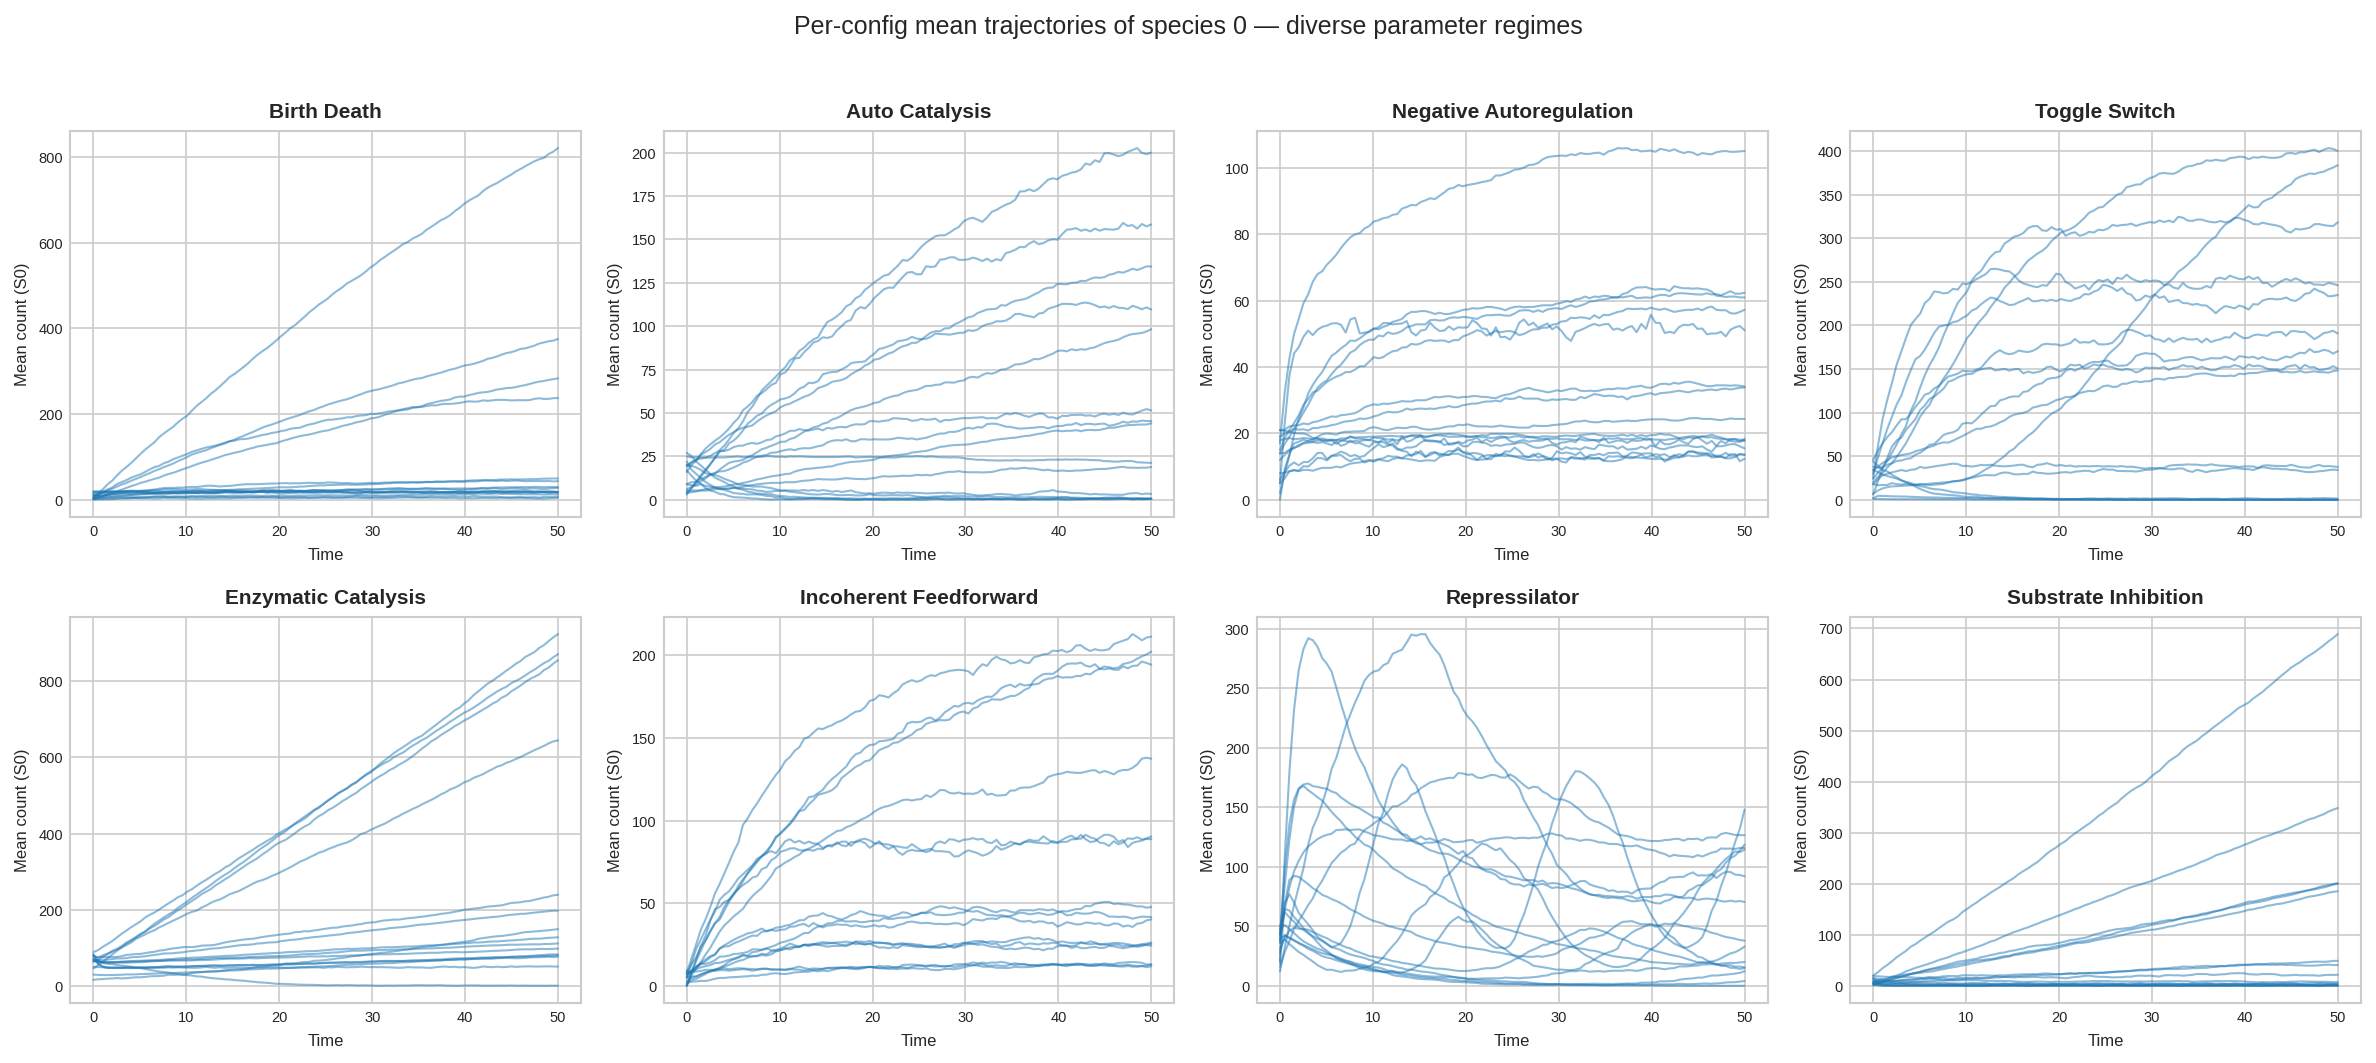

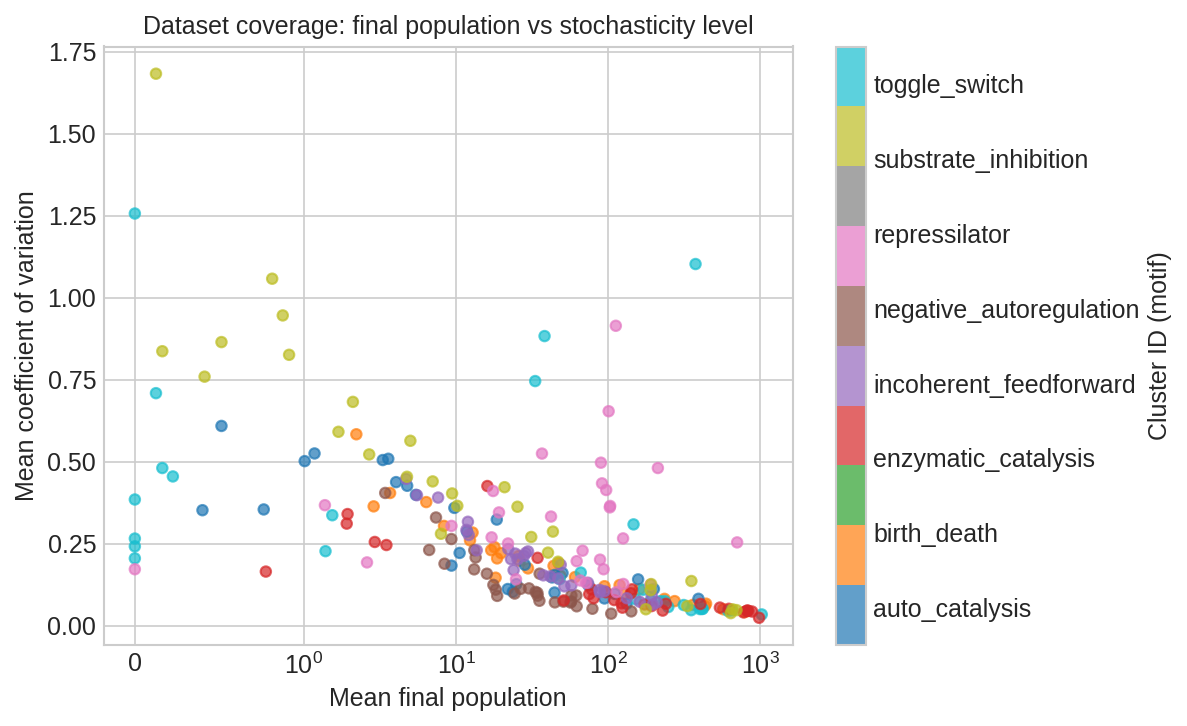

In [13]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset

dataset = CRNTrajectoryDataset("data_cache/demo_dataset/dataset.pt")

# Group items by motif label
by_label: dict[str, list] = {}
for item in dataset:
    by_label.setdefault(item.motif_label, []).append(item)

# For each motif, plot the mean trajectory of species 0 across all configs
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes_flat = axes.flatten()

for ax, (label, items) in zip(axes_flat, by_label.items()):
    t = items[0].times.numpy()
    for item in items[:15]:  # up to 15 configs
        mean_traj = item.trajectories[:, :, 0].mean(dim=0).numpy()
        ax.plot(t, mean_traj, alpha=0.5, lw=1.0, color=TAB10[0])
    ax.set_title(label.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("Mean count (S0)", fontsize=8)
    ax.tick_params(labelsize=7)

# Hide any unused axes
for ax in axes_flat[len(by_label):]:
    ax.set_visible(False)

plt.suptitle(
    "Per-config mean trajectories of species 0 — diverse parameter regimes",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

# Final state scatter: mean final population vs CV
final_means, final_cvs, cluster_ids_list = [], [], []
for item in dataset:
    traj = item.trajectories[:, :, 0]  # (M, T)
    final_mean = traj[:, -10:].mean().item()
    cv = (traj.std(dim=0).mean() / (traj.mean() + 1e-8)).item()
    final_means.append(final_mean)
    final_cvs.append(cv)
    cluster_ids_list.append(item.cluster_id)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    final_means, final_cvs,
    c=cluster_ids_list, cmap="tab10", alpha=0.7, s=25,
    vmin=-0.5, vmax=max(cluster_ids_list) + 0.5,
)
cbar = plt.colorbar(scatter, ax=ax, ticks=sorted(set(cluster_ids_list)))
cbar.set_label("Cluster ID (motif)")
cbar.set_ticklabels([summary.cluster_id_map and {v: k for k, v in summary.cluster_id_map.items()}.get(i, str(i)) for i in sorted(set(cluster_ids_list))])
ax.set_xlabel("Mean final population")
ax.set_ylabel("Mean coefficient of variation")
ax.set_title("Dataset coverage: final population vs stochasticity level")
ax.set_xscale("symlog", linthresh=1)
plt.tight_layout()
plt.show()

## 9. Full-Scale Dataset (Optional)

To generate a production-scale dataset (~15 000 viable items), use the default config:

```python
from crn_surrogate.data.generation import DataGenerationPipeline, GenerationConfig

config = GenerationConfig(
    n_samples_per_motif=500,
    n_ssa_trajectories=32,
    simulation_time=100.0,
    n_timepoints=200,
    output_dir="data_cache/full_dataset",
)
summary = DataGenerationPipeline(config).run()
print(f"Generated {summary.total_items} items")
```

Expected pass rates (rough estimates from the curation criteria):
- Birth-death: ~90% pass rate
- Auto-catalysis: ~70% (constraint k_deg > k_cat reduces sample pool)
- Toggle switch: ~75%
- Repressilator: ~60% (requires cooperativity n ≥ 2 AND initial asymmetry)
- Others: ~80–85%

The balancing step caps any over-represented class at 2× the median count, so the final dataset will be roughly uniform across motifs.

Once generated, load with:

```python
from crn_surrogate.data.dataset import CRNTrajectoryDataset

full_dataset = CRNTrajectoryDataset("data_cache/full_dataset/dataset.pt")
```

## Summary of Changes

This notebook demonstrated the following additions to the `crn_surrogate` codebase:

### New propensity types (`crn_surrogate.crn.propensities`)
| Factory | Params | Tensor layout (8 slots) |
|---------|--------|------------------------|
| `hill_repression(k_max, k_half, n, idx)` | `HillRepressionParams` | `[k_max, k_half, n, idx, 0, 0, 0, 0]` |
| `hill_activation_repression(...)` | `HillActivationRepressionParams` | `[k_max, k_act, n_act, act_idx, k_rep, n_rep, rep_idx, 0]` |
| `substrate_inhibition(V_max, K_m, K_i, idx)` | `SubstrateInhibitionParams` | `[V_max, K_m, K_i, idx, 0, 0, 0, 0]` |

### Updated `PropensityType` enum (`crn_surrogate.encoder.tensor_repr`)
Added: `HILL_REPRESSION=4`, `HILL_ACTIVATION_REPRESSION=5`, `SUBSTRATE_INHIBITION=6`

### Updated defaults
- `EncoderConfig.max_propensity_params`: 4 → **8**
- `EncoderConfig.n_propensity_types`: 4 → **7**

### Extended `TrajectoryItem` (`crn_surrogate.data.dataset`)
Added optional fields: `motif_label: str`, `cluster_id: int`, `params: dict`

`CRNTrajectoryDataset` now also accepts a file path. `CRNCollator` now returns `cluster_ids` in the batch dict.

### New sub-package: `crn_surrogate.data.generation`
- `MotifType` enum — 8 canonical motifs
- `MotifFactory` ABC + 8 concrete factories
- `ParameterSampler` — log-uniform rates, uniform Hill coefficients, rejection sampling
- `ViabilityFilter` + `CurationResult` — 6-criterion curation
- `CRNComposer` — compose two CRNs by merging shared species
- `DataGenerationPipeline` — orchestrates sample → simulate → curate → balance → save